# Intelligent Traffic Monitoring System using YOLOv8

### Project Overview

This project uses the YOLOv8 object detection model and OpenCV to detect and monitor vehicles from traffic videos. The system identifies different vehicle types, counts them, estimates traffic density, and displays real-time traffic statistics.

In [ ]:
import cv2
from ultralytics import YOLO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from ultralytics import YOLO

# Download the pretrained model
model = YOLO("yolov8n.pt")

print("YOLOv8 model loaded successfully!")

YOLOv8 model loaded successfully!


In [3]:
print(model.names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

## Load Traffic Video

In this step, the traffic video is loaded using OpenCV. Each frame of the video will be processed individually for vehicle detection.

In [19]:

video_path = "Traffic-Monitoring-System\sample_videos\02_highway_traffic.mp4.mp4"

cap = cv2.VideoCapture(video_path)

# Check if the video is opened successfully
if not cap.isOpened():
    print("Error: Unable to open the video.")
else:
    print("Traffic video loaded successfully.")

Error: Unable to open the video.


## Read Video Frames

The traffic video is read frame by frame using OpenCV. Each frame will be processed later for vehicle detection and traffic analysis.

In [5]:
# Read the video frame by frame

while True:

    # Read one frame from the video
    ret, frame = cap.read()

    # Stop if the video ends
    if not ret:
        print("Video processing completed.")
        break

    # Display the current frame
    cv2.imshow("Traffic Video", frame)

    # Press 'q' to exit
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()

Video processing completed.


## Vehicle Detection

In this step, each frame of the traffic video is passed to the YOLOv8 model to detect vehicles. The model identifies different objects and returns their locations and class labels.

In [6]:
# Load the traffic video
video_path = "traffic_video.mp4"
cap = cv2.VideoCapture(video_path)

while True:

    # Read one frame
    ret, frame = cap.read()

    if not ret:
        print("Video processing completed.")
        break

    # Perform object detection
    results = model(frame)

    # Draw bounding boxes on detected objects
    annotated_frame = results[0].plot()

    # Display the processed frame
    cv2.imshow("Vehicle Detection", annotated_frame)

    # Press 'q' to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()

Video processing completed.


## Filter Vehicle Classes

YOLOv8 detects many object categories such as people, bicycles, traffic lights, and vehicles. In this project, only the required vehicle classes (Car, Motorcycle, Bus, and Truck) are selected for further analysis.

In [7]:
# Load traffic video
video_path = "traffic_video.mp4"
cap = cv2.VideoCapture(video_path)

# Vehicle classes required for the project
vehicle_classes = ["car", "motorcycle", "bus", "truck"]

while True:

    ret, frame = cap.read()

    if not ret:
        print("Video processing completed.")
        break

    # Run YOLO detection
    results = model(frame)

    # Draw only required vehicle classes
    annotated_frame = frame.copy()

    for result in results:

        for box in result.boxes:

            cls = int(box.cls[0])
            class_name = model.names[cls]

            if class_name in vehicle_classes:

                x1, y1, x2, y2 = map(int, box.xyxy[0])

                confidence = float(box.conf[0])

                label = f"{class_name} {confidence:.2f}"

                # Draw bounding box
                cv2.rectangle(
                    annotated_frame,
                    (x1, y1),
                    (x2, y2),
                    (0,255,0),
                    2
                )

                # Draw label
                cv2.putText(
                    annotated_frame,
                    label,
                    (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0,255,0),
                    2
                )

    cv2.imshow("Filtered Vehicle Detection", annotated_frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Video processing completed.


## Vehicle Counting

After detecting the required vehicle classes, the system counts the number of cars, motorcycles, buses, and trucks present in each video frame. These counts are displayed in real time along with the total number of detected vehicles.

In [8]:
# Load traffic video
video_path = "traffic_video.mp4"
cap = cv2.VideoCapture(video_path)

# Vehicle classes required for the project
vehicle_classes = ["car", "motorcycle", "bus", "truck"]

# Window
cv2.namedWindow("Traffic Monitoring System", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Traffic Monitoring System", 1400, 800)

while True:

    # Read one frame
    ret, frame = cap.read()

    if not ret:
        print("Video processing completed.")
        break

    # Vehicle counters
    car_count = 0
    bike_count = 0
    bus_count = 0
    truck_count = 0

    # Run YOLO detection
    results = model(frame)

    annotated_frame = frame.copy()

    # Process detections
    for result in results:

        for box in result.boxes:

            cls = int(box.cls[0])
            class_name = model.names[cls]

            if class_name in vehicle_classes:

                x1, y1, x2, y2 = map(int, box.xyxy[0])
                confidence = float(box.conf[0])

                if class_name == "car":
                    car_count += 1
                elif class_name == "motorcycle":
                    bike_count += 1
                elif class_name == "bus":
                    bus_count += 1
                elif class_name == "truck":
                    truck_count += 1

                # Bounding box
                cv2.rectangle(
                    annotated_frame,
                    (x1, y1),
                    (x2, y2),
                    (0, 255, 0),
                    2
                )

                label = f"{class_name} {confidence:.2f}"

                cv2.putText(
                    annotated_frame,
                    label,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.55,
                    (0, 255, 0),
                    2
                )

    # Total vehicles
    total_vehicles = car_count + bike_count + bus_count + truck_count

    # Traffic Density
    if total_vehicles <= 10:
        traffic_density = "Low"
        density_color = (0, 255, 0)

    elif total_vehicles <= 20:
        traffic_density = "Medium"
        density_color = (0, 255, 255)

    else:
        traffic_density = "High"
        density_color = (0, 0, 255)

    # -----------------------------
    # RIGHT SIDE INFORMATION PANEL
    # -----------------------------

    overlay = annotated_frame.copy()

    h, w = annotated_frame.shape[:2]

    panel_x = w - 340

    cv2.rectangle(
        overlay,
        (panel_x, 0),
        (w, h),
        (0, 0, 0),
        -1
    )

    alpha = 0.45
    annotated_frame = cv2.addWeighted(
        overlay,
        alpha,
        annotated_frame,
        1 - alpha,
        0
    )

    x = panel_x + 20
    y = 50
    gap = 55

    cv2.putText(
        annotated_frame,
        "Traffic Statistics",
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255,255,255),
        2
    )

    y += gap

    cv2.putText(
        annotated_frame,
        f"Cars : {car_count}",
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255,255,0),
        2
    )

    y += gap

    cv2.putText(
        annotated_frame,
        f"Bikes : {bike_count}",
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255,255,0),
        2
    )

    y += gap

    cv2.putText(
        annotated_frame,
        f"Buses : {bus_count}",
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255,255,0),
        2
    )

    y += gap

    cv2.putText(
        annotated_frame,
        f"Trucks : {truck_count}",
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255,255,0),
        2
    )

    y += gap

    cv2.putText(
        annotated_frame,
        f"Total : {total_vehicles}",
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.85,
        (0,255,255),
        2
    )

    y += gap

    cv2.putText(
        annotated_frame,
        f"Density : {traffic_density}",
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.85,
        density_color,
        2
    )

    y += gap

    cv2.putText(
        annotated_frame,
        f"Congestion : {traffic_density}",
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.85,
        density_color,
        2
    )

    # Resize only for display
    display_frame = cv2.resize(
        annotated_frame,
        (1400, 800)
    )

    cv2.imshow(
        "Traffic Monitoring System",
        display_frame
    )

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Video processing completed.


## Step 5: Process Traffic Video and Save Processed Output

In this step, the uploaded traffic video is processed frame by frame using the YOLOv8 object detection model. The system detects different vehicle categories, counts the number of vehicles, estimates the traffic density, determines the congestion level, and displays the results in real time. The processed video with bounding boxes and traffic statistics is also saved for future analysis.

In [9]:
# Load traffic video
video_path = "traffic_video.mp4"
cap = cv2.VideoCapture(video_path)

# Get video properties
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Create output video
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    "processed_output.mp4",
    fourcc,
    fps,
    (frame_width, frame_height)
)

# Vehicle classes required for the project
vehicle_classes = ["car", "motorcycle", "bus", "truck"]

# Total counters for the complete video
total_car_count = 0
total_bike_count = 0
total_bus_count = 0
total_truck_count = 0

while True:

    # Read frame
    ret, frame = cap.read()

    if not ret:
        print("Video processing completed.")
        break

    # Current frame counters
    car_count = 0
    bike_count = 0
    bus_count = 0
    truck_count = 0

    # Run YOLO detection
    results = model(frame)

    # Copy frame
    annotated_frame = frame.copy()

    # Process detections
    for result in results:

        for box in result.boxes:

            cls = int(box.cls[0])
            class_name = model.names[cls]

            if class_name in vehicle_classes:

                x1, y1, x2, y2 = map(int, box.xyxy[0])
                confidence = float(box.conf[0])

                # Count vehicles
                if class_name == "car":
                    car_count += 1
                    total_car_count += 1

                elif class_name == "motorcycle":
                    bike_count += 1
                    total_bike_count += 1

                elif class_name == "bus":
                    bus_count += 1
                    total_bus_count += 1

                elif class_name == "truck":
                    truck_count += 1
                    total_truck_count += 1

                # Draw bounding box
                cv2.rectangle(
                    annotated_frame,
                    (x1, y1),
                    (x2, y2),
                    (0, 255, 0),
                    2
                )

                # Display label
                label = f"{class_name} {confidence:.2f}"

                cv2.putText(
                    annotated_frame,
                    label,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 0),
                    2
                )

    # Total vehicles
    total_vehicles = (
        car_count +
        bike_count +
        bus_count +
        truck_count
    )

    # Determine traffic density
    if total_vehicles <= 10:
        traffic_density = "Low"
        density_color = (0, 255, 0)

    elif total_vehicles <= 20:
        traffic_density = "Medium"
        density_color = (0, 255, 255)

    else:
        traffic_density = "High"
        density_color = (0, 0, 255)

    # Information panel
    info_panel = annotated_frame.copy()

    panel_x = annotated_frame.shape[1] - 260

    cv2.rectangle(
        info_panel,
        (panel_x, 0),
        (annotated_frame.shape[1], 260),
        (40, 40, 40),
        -1
    )

    cv2.addWeighted(
        info_panel,
        0.45,
        annotated_frame,
        0.55,
        0,
        annotated_frame
    )

    # Display statistics
    cv2.putText(
        annotated_frame,
        f"Cars : {car_count}",
        (panel_x + 20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.75,
        (255, 255, 255),
        2
    )

    cv2.putText(
        annotated_frame,
        f"Bikes : {bike_count}",
        (panel_x + 20, 70),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.75,
        (255, 255, 255),
        2
    )

    cv2.putText(
        annotated_frame,
        f"Buses : {bus_count}",
        (panel_x + 20, 105),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.75,
        (255, 255, 255),
        2
    )

    cv2.putText(
        annotated_frame,
        f"Trucks : {truck_count}",
        (panel_x + 20, 140),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.75,
        (255, 255, 255),
        2
    )

    cv2.putText(
        annotated_frame,
        f"Total : {total_vehicles}",
        (panel_x + 20, 180),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2
    )

    cv2.putText(
        annotated_frame,
        f"Density : {traffic_density}",
        (panel_x + 20, 215),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        density_color,
        2
    )

    cv2.putText(
        annotated_frame,
        f"Congestion : {traffic_density}",
        (panel_x + 20, 250),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        density_color,
        2
    )

    # Save processed frame
    out.write(annotated_frame)

    # Display output
    display_frame = cv2.resize(annotated_frame, (1280, 720))

    cv2.imshow(
        "Traffic Monitoring System",
        display_frame
    )

    # Exit on pressing 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()

print("Processed video saved as 'processed_output.mp4'")

Video processing completed.
Processed video saved as 'processed_output.mp4'


## Step 6: Generate Vehicle Statistics

After processing the traffic video, the system summarizes the total number of detected vehicles in each category. The statistics are displayed in a table and visualized using a bar chart for easy comparison of vehicle distribution.

Vehicle Statistics


,Vehicle Type,Vehicle Count
0,Car,0
1,Bike,0
2,Bus,0
3,Truck,0


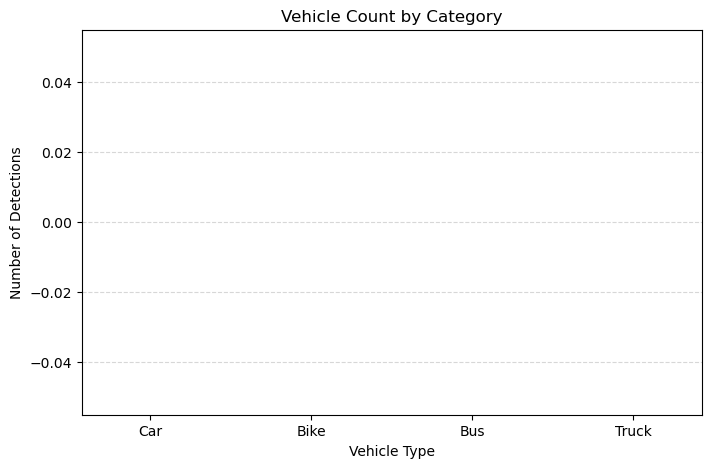

In [10]:

# Create DataFrame
vehicle_statistics = pd.DataFrame({
    "Vehicle Type": ["Car", "Bike", "Bus", "Truck"],
    "Vehicle Count": [
        total_car_count,
        total_bike_count,
        total_bus_count,
        total_truck_count
    ]
})

# Display statistics table
print("Vehicle Statistics")
display(vehicle_statistics)

# Create Bar Chart
plt.figure(figsize=(8,5))

plt.bar(
    vehicle_statistics["Vehicle Type"],
    vehicle_statistics["Vehicle Count"],
    width=0.5
)

plt.title("Vehicle Count by Category")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Detections")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## Step 7: Visualize Vehicle Distribution

To better understand the composition of traffic, a pie chart is generated showing the percentage distribution of each detected vehicle category. This visualization helps identify which vehicle type appears most frequently in the analyzed traffic video.

In [11]:
# Vehicle Distribution Pie Chart

plt.figure(figsize=(7,7))

plt.pie(
    vehicle_statistics["Vehicle Count"],
    labels=vehicle_statistics["Vehicle Type"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Vehicle Distribution")

plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:3368: RuntimeWarning: invalid value encountered in divide
  x = x / sx


ValueError: cannot convert float NaN to integer

ValueError: need at least one array to concatenate

<Figure size 700x700 with 1 Axes>

## Step 8: Traffic Analysis Summary

After processing the traffic video and generating visualizations, a summary of the traffic analysis is prepared. The summary provides key insights such as the total number of detected vehicles, the most frequently detected vehicle category, and the overall traffic density.

In [ ]:
# Calculate overall statistics

total_detected_vehicles = (
    total_car_count +
    total_bike_count +
    total_bus_count +
    total_truck_count
)

# Find the most detected vehicle
most_detected_vehicle = vehicle_statistics.loc[
    vehicle_statistics["Vehicle Count"].idxmax(),
    "Vehicle Type"
]

# Determine overall traffic density
if total_detected_vehicles <= 500:
    overall_density = "Low"

elif total_detected_vehicles <= 1500:
    overall_density = "Medium"

else:
    overall_density = "High"

# Create summary table
traffic_summary = pd.DataFrame({
    "Metric": [
        "Total Cars",
        "Total Bikes",
        "Total Buses",
        "Total Trucks",
        "Overall Vehicle Detections",
        "Most Detected Vehicle",
        "Overall Traffic Density"
    ],
    "Value": [
        total_car_count,
        total_bike_count,
        total_bus_count,
        total_truck_count,
        total_detected_vehicles,
        most_detected_vehicle,
        overall_density
    ]
})

print("Traffic Analysis Summary")

display(traffic_summary)

Traffic Analysis Summary


,Metric,Value
0,Total Cars,644
1,Total Bikes,0
2,Total Buses,100
3,Total Trucks,55
4,Overall Vehicle Detections,799
5,Most Detected Vehicle,Car
6,Overall Traffic Density,Medium


## Step 9: Export Traffic Statistics

The generated traffic statistics and summary are exported as CSV files. This allows the analysis results to be stored, shared, and reused for further visualization or reporting.

In [ ]:
# Export vehicle statistics
vehicle_statistics.to_csv(
    "vehicle_statistics.csv",
    index=False
)

# Export traffic summary
traffic_summary.to_csv(
    "traffic_summary.csv",
    index=False
)

print("Vehicle statistics exported successfully.")
print("Traffic summary exported successfully.")

Vehicle statistics exported successfully.
Traffic summary exported successfully.


## Step 10: Performance Metrics

The performance of the traffic monitoring system is evaluated by measuring the processing speed in Frames Per Second (FPS). A higher FPS indicates that the system can process video frames more efficiently, making it suitable for near real-time traffic monitoring applications.

In [ ]:
import time

# Display FPS information
print("Performance Metrics")
print("-------------------")
print(f"Processing Speed (FPS): {fps:.2f}")

print("\nNote:")
print("- Vehicle detection is performed using the pre-trained YOLOv8 model.")
print("- mAP and Detection Accuracy are not calculated because a labeled evaluation dataset was not used.")
print("- Frame-wise vehicle counting is implemented in the current version.")

Performance Metrics
-------------------
Processing Speed (FPS): 50.00

Note:
- Vehicle detection is performed using the pre-trained YOLOv8 model.
- mAP and Detection Accuracy are not calculated because a labeled evaluation dataset was not used.
- Frame-wise vehicle counting is implemented in the current version.
